# Benchmark run analysis

Comparing benchmark runs

In [10]:
import pandas as pd
import numpy as np
from pathlib import Path

In [ ]:
RUN_A = 'store/phlag/gaussian/repulsion/'
RUN_B = 'store/phlag/gaussian/var2x/repulsion/w50k_s1k/annealing'

run_dir_a = Path(RUN_A)
run_dir_b = Path(RUN_B)

runs_path_a = run_dir_a / "runs.tsv"
runs_path_b = run_dir_b / "runs.tsv"

In [12]:
df_a = pd.read_csv(runs_path_a, sep="\t")
df_b = pd.read_csv(runs_path_b, sep="\t")

In [13]:
PATH_COLUMNS = ["report_path"]
PANEL_COLUMNS = ["in_panel_a", "in_panel_b", "in_panel_relerr", "in_panel_em_divergence", "anomaly_fraction_source"]
ID_COLUMNS = ["run_id", "source_leaf", 'x_variable']

df_a = df_a.drop(columns=PATH_COLUMNS + PANEL_COLUMNS+ID_COLUMNS, errors="ignore")
df_b = df_b.drop(columns=PATH_COLUMNS + PANEL_COLUMNS+ID_COLUMNS, errors="ignore")

In [14]:
df_b.columns

Index(['category', 'subcategory', 'column', 'pattern', 'anomaly_fraction',
       'fraction_bin', 'x_value', 'x_bin', 'branch_length_cu', 'clade_name',
       'clade_number', 'tpr', 'fpr', 'precision', 'f1', 'accuracy', 'roc_auc',
       'tp', 'fp', 'fn', 'tn', 'n_windows', 'label_flipped', 'in_panel_hd_alt',
       'hd_bin', 'mean_relerr_agg', 'covar_relerr_agg', 'em_hd', 'em_gt_hd',
       'transition_null_to_null', 'transition_null_to_alt',
       'transition_alt_to_null', 'transition_alt_to_alt', 'bic',
       'log_likelihood', 'n_trainable_params', 'clip_activation_count',
       'clip_activation_rate', 'clip_unsafe', 'relerr_ABBA_Null_mean',
       'relerr_ABBA_Null_std', 'relerr_ABBA_Alt_mean', 'relerr_ABBA_Alt_std',
       'relerr_BABA_Null_mean', 'relerr_BABA_Null_std', 'relerr_BABA_Alt_mean',
       'relerr_BABA_Alt_std', 'relerr_AABB_Null_mean', 'relerr_AABB_Null_std',
       'relerr_AABB_Alt_mean', 'relerr_AABB_Alt_std', 'exclusion'],
      dtype='object')

In [15]:
df_b['n_windows'].unique()

array([5951])

In [16]:
df_a['f1'].std()

0.3163512827843377

In [17]:
df_b['f1'].std()

0.3420026281884354

In [18]:
total = df_b['n_windows'][0]
alt_a = df_a['fp'] + df_a['tp']
alt_b = df_b['fp'] + df_b['tp']
print(np.mean(alt_a / total), np.mean(alt_b / total))

0.3827420461547079 0.31744364692608684


In [19]:
df_c = df_a.copy()
f1_std_change = (
    df_b.groupby(['category', 'subcategory'])['f1'].std()
    - df_a.groupby(['category', 'subcategory'])['f1'].std()
)
print(f1_std_change)
# print(df_c.groupby(['category', 'subcategory'])['em_bd'].mean())

category       subcategory
10X            down           0.036420
               up             0.007979
admixture      high           0.032497
               low            0.011620
recombination  down           0.031140
               up             0.020127
Name: f1, dtype: float64


In [20]:
print(np.mean(df_a['fp']))
print(np.mean(df_b['fp']))
print(np.mean(df_a['tn']))
print(np.mean(df_b['tn']))
print(np.mean(df_a['fn']))
print(np.mean(df_b['fn']))
print(np.mean(df_a['tp']))
print(np.mean(df_b['tp']))

1656.8794642857142
1306.2098214285713
3530.120535714286
3880.7901785714284
143.18154761904762
181.10267857142858
620.8184523809524
582.8973214285714


In [21]:
filter = 'x_bin'
target = 'f1'
value1 = "(0,0.1]"
value2 = "(0.1,0.25]"
low_drop = np.mean(df_b[df_b[filter]==value1][target] - df_a[df_a[filter]==value1][target])
high_drop = np.mean(df_b[df_b[filter]==value2][target] - df_a[df_a[filter]==value2][target])
print(low_drop, high_drop)

0.027653846153846154 nan


## Heatmap comparison: signed change between runs

In [22]:
import re
import matplotlib
import matplotlib.pyplot as plt
from bench.benchmark import DEFAULT_CONCAT_PATTERNS

def hd_bin_rank_grid(df, metric):
    d = df[df['in_panel_hd_alt']]
    order = sorted(d['hd_bin'].unique(), key=lambda s: float(re.split(r'[,\]]', s.strip('[]()'))[0]))
    rank = {label: i for i, label in enumerate(order)}
    d = d.assign(hd_rank=d['hd_bin'].map(rank))
    values = d.groupby(['hd_rank', 'pattern'])[metric].mean().unstack('pattern').reindex(columns=DEFAULT_CONCAT_PATTERNS)
    counts = d.groupby(['hd_rank', 'pattern']).size().unstack('pattern').reindex(columns=DEFAULT_CONCAT_PATTERNS)
    return values, counts, order

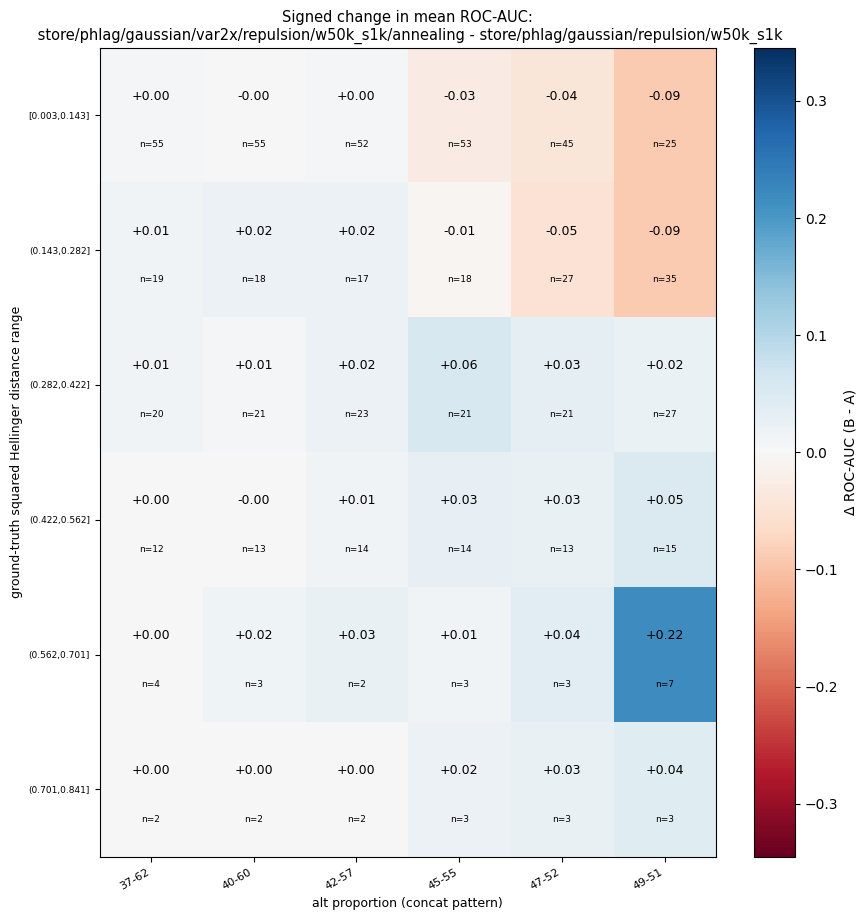

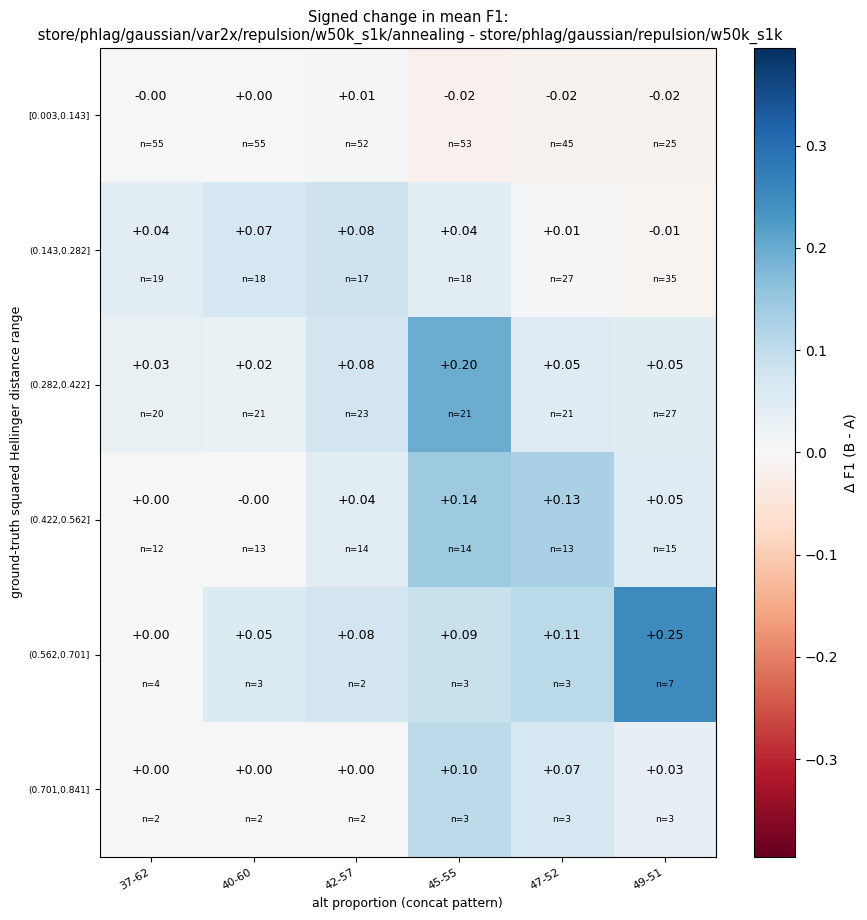

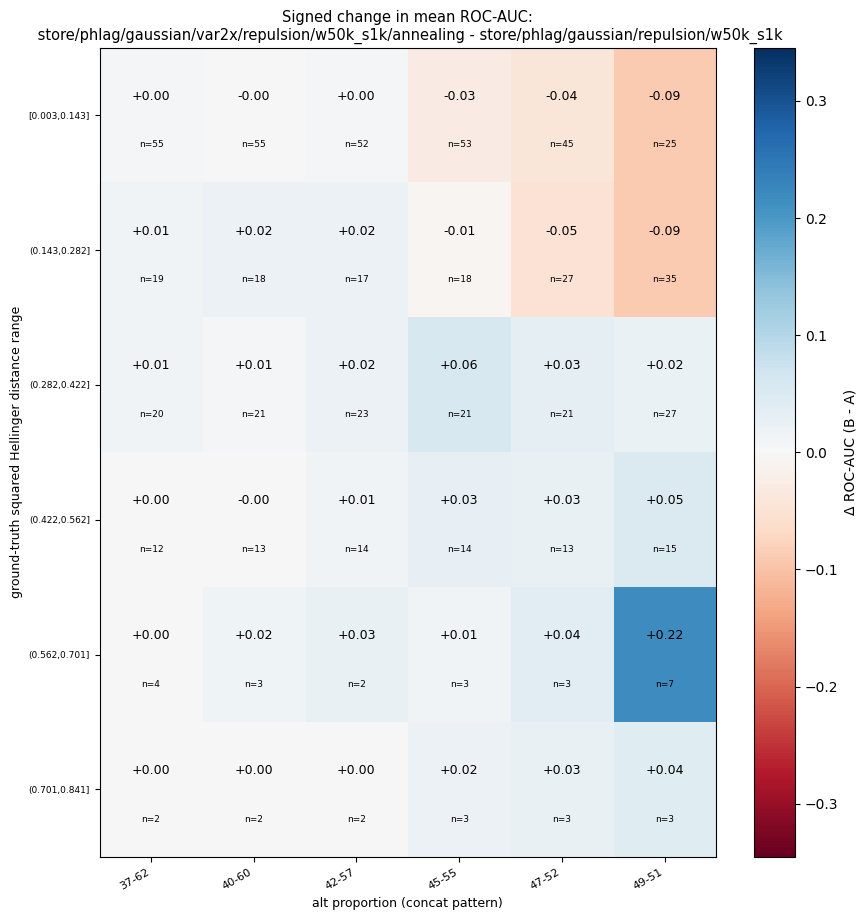

In [23]:
def plot_signed_diff(values_a, counts_a, labels_a, values_b, counts_b, labels_b, metric_label):
    diff = values_b - values_a
    n_a = counts_a.reindex(index=diff.index, columns=diff.columns)
    n_b = counts_b.reindex(index=diff.index, columns=diff.columns)

    vmax = np.nanmax(np.abs(diff.values))
    vmax = (vmax if vmax > 0 else 1.0) * 1.6

    fig, ax = plt.subplots(figsize=(1.15 * len(diff.columns) + 2.0, 1.25 * len(diff.index) + 1.8))
    cmap = matplotlib.colormaps["RdBu"].copy()
    cmap.set_bad(color="#e1e0d9")
    masked = np.ma.masked_invalid(diff.values)
    im = ax.imshow(masked, cmap=cmap, vmin=-vmax, vmax=vmax, aspect="auto")

    for r, rank in enumerate(diff.index):
        for c in range(diff.shape[1]):
            v = diff.values[r, c]
            if np.isnan(v):
                continue
            ax.text(c, r - 0.14, f"{v:+.2f}", ha="center", va="center", fontsize=9)
            na = n_a.values[r, c]
            nb = n_b.values[r, c]
            na = 0 if np.isnan(na) else int(na)
            nb = 0 if np.isnan(nb) else int(nb)
            ax.text(c, r + 0.22, f"n={na}", ha="center", va="center", fontsize=6.5)

    def row_label(rank):
        a = labels_a[rank] if rank < len(labels_a) else "?"
        b = labels_b[rank] if rank < len(labels_b) else "?"
        return f"{a}"

    ax.set_xticks(range(len(diff.columns)))
    ax.set_xticklabels(diff.columns, rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(len(diff.index)))
    ax.set_yticklabels([row_label(rank) for rank in diff.index], fontsize=6.5)
    ax.set_xlabel("alt proportion (concat pattern)", fontsize=9)
    ax.set_ylabel("ground-truth squared Hellinger distance range", fontsize=9)
    fig.colorbar(im, ax=ax, label=f"Δ {metric_label} (B - A)")
    ax.set_title(f"Signed change in mean {metric_label}:\n {RUN_B} - {RUN_A}", fontsize=10.5)
    fig.tight_layout()
    return fig

plot_signed_diff(*hd_bin_rank_grid(df_a, 'f1'), *hd_bin_rank_grid(df_b, 'f1'), "F1")
plot_signed_diff(*hd_bin_rank_grid(df_a, 'roc_auc'), *hd_bin_rank_grid(df_b, 'roc_auc'), "ROC-AUC")

## Parameter sweeps: window size / step size vs. metrics

In [24]:
from phlag.caster import format_val

SWEEP_METRICS = ["em_hd", "roc_auc", "f1"]
SWEEP_METRIC_TITLES = {"em_hd": "Fitted Hellinger distance^2", "roc_auc": "ROC-AUC", "f1": "F1"}

def _sweep_run_dir(window, step):
    return Path("store/phlag/gaussian") / f"w{format_val(window)}_s{format_val(step)}"

def _sweep_metric_means(window, step, metrics=SWEEP_METRICS):
    analysis_path = _sweep_run_dir(window, step) / "analysis.tsv"
    if not analysis_path.exists():
        print(f"[skip] {analysis_path} does not exist")
        return None
    analysis_df = pd.read_csv(analysis_path, sep="\t")
    result = {}
    for metric in metrics:
        row = analysis_df[analysis_df["metric"] == metric]
        if row.empty:
            print(f"[skip] {analysis_path} has no row for metric={metric!r}")
            continue
        result[metric] = row["mean_value"].iloc[0]
    return result

In [25]:
def _plot_metric_sweep(pairs, x_labels, x_axis_label, suptitle):
    means_by_pair = {(w, s): _sweep_metric_means(w, s) for w, s in set(pairs)}
    if all(means is None for means in means_by_pair.values()):
        print(f"{suptitle}: no runs with analysis.tsv found for the given sizes")
        return None

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, metric in zip(axes, SWEEP_METRICS):
        bar_labels, bar_values = [], []
        for (w, s), label in zip(pairs, x_labels):
            means = means_by_pair[(w, s)]
            if means is None or metric not in means:
                if means is not None:
                    print(f"[skip] no {metric!r} value for w={w} s={s}")
                continue
            bar_labels.append(label)
            bar_values.append(means[metric])
        ax.bar(bar_labels, bar_values)
        ax.set_xlabel(x_axis_label)
        ax.set_ylabel("mean value")
        ax.set_title(SWEEP_METRIC_TITLES[metric])

    fig.suptitle(suptitle)
    fig.tight_layout()
    return fig

def plot_size_sweep(window_sizes, step_sizes):
    w_is_list = isinstance(window_sizes, (list, tuple))
    s_is_list = isinstance(step_sizes, (list, tuple))

    if w_is_list and s_is_list:
        if len(window_sizes) != len(step_sizes):
            raise ValueError(
                f"window_sizes and step_sizes must be the same length when both "
                f"are lists, got {len(window_sizes)} and {len(step_sizes)}"
            )
    elif w_is_list:
        step_sizes = [step_sizes] * len(window_sizes)
    elif s_is_list:
        window_sizes = [window_sizes] * len(step_sizes)
    else:
        window_sizes, step_sizes = [window_sizes], [step_sizes]

    pairs = list(zip(window_sizes, step_sizes))
    if w_is_list and not s_is_list:
        labels, x_axis_label = [format_val(w) for w in window_sizes], "window size"
    elif s_is_list and not w_is_list:
        labels, x_axis_label = [format_val(s) for s in step_sizes], "step size"
    else:
        labels = [f"w{format_val(w)}_s{format_val(s)}" for w, s in pairs]
        x_axis_label = "window_step size"

    return _plot_metric_sweep(pairs, labels, x_axis_label, f"Size sweep ({x_axis_label})")

Demo: currently only `store/phlag/gaussian/w50k_s1k` exists, so each call below produces a single bar per subplot. Extend `window_sizes`/`step_sizes` as more runs are created with `bench/benchmark.py --create`.

In [26]:
plot_size_sweep(window_sizes=[50000], step_sizes=1000)
plot_size_sweep(window_sizes=50000, step_sizes=[1000])

[skip] store/phlag/gaussian/w50k_s1k/analysis.tsv does not exist
Size sweep (window size): no runs with analysis.tsv found for the given sizes
[skip] store/phlag/gaussian/w50k_s1k/analysis.tsv does not exist
Size sweep (step size): no runs with analysis.tsv found for the given sizes
